# Cooke Triplet — Chief-Ray Distortion

A classic three-element photographic objective (H. Dennis Taylor, 1893):
positive-negative-positive, stop between the second and third elements.
Prescription reconstructed from the "oslo cooke triplet example 50mm f/4
20deg" reference lens distributed with the open-source
[rayopt-notebooks](https://github.com/quartiq/rayopt-notebooks) project
(`triplet.ipynb`); glass indices (SK16, F4) are d-line (587.6 nm) values
from the SCHOTT optical glass pocket catalog. It is a textbook-scale
example, not a claim of a specific commercial lens.

The triplet's asymmetric aperture-stop position (offset toward the rear,
between the negative and rear positive elements) is the classic source of
a small but nonzero *linear* asymmetry in the object-to-image map — this
notebook measures it directly with the chief-ray distortion metric, both
as a dense distortion-vs-field curve and as the classic warped-grid
display used in optical design software.

In [1]:
from importlib import resources
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from raytracer.sequential import (
    FieldPoint, OpticalSystem, ParaxialModel, SequentialTracer,
    chief_ray_slopes, solve_object_plane, trace_from_object,
)
from raytracer.analysis import distortion_grid
from raytracer.viz import plots

CSV = resources.files("raytracer") / "data" / "cooke_triplet_prescription.csv"
system = OpticalSystem.from_prescription(CSV)
tracer = SequentialTracer(system)
conjugate = solve_object_plane(tracer)
efl = ParaxialModel(system).effective_focal_length()

print(f"{len(system)} surfaces, stop at index {system.stop_index}")
print(f"EFL = {efl:.3f} mm (design: 50 mm)")
print(f"recovered object plane z = {conjugate.object_z:.1f} mm "
      f"(a large finite stand-in for the design's object at infinity)")
print(f"magnification = {conjugate.magnification:.6f}")

7 surfaces, stop at index 4
EFL = 50.056 mm (design: 50 mm)
recovered object plane z = 13096.3 mm (a large finite stand-in for the design's object at infinity)
magnification = 0.003812


## Distortion vs. field angle

The object is effectively at infinity, so field points are parametrized by
angle rather than object height (matching the design's own convention:
"50mm f/4 20deg" — a 20° total field, i.e. a 10° half field). Each angle
converts to an object height at the recovered finite conjugate; the chief
ray (through the aperture-stop center) is solved with the general 2-D
solver `chief_ray_slopes`, and its image-plane height is compared against
the ideal `magnification * y` line.

The curve is sampled densely (steps of 0.5°) out to a bit past the
design's stated 10° half field, not just at a handful of points, so the
shape of the curve — not just a few widely-spaced dots — is what carries
the result.

 field (deg) |  image y (mm) |  distortion (um) | relative (ppm)
         0.0 |        0.0000 |            0.000 |            0.0
         0.5 |        0.4356 |            0.001 |            1.9
         1.0 |        0.8713 |            0.007 |            7.6
         1.5 |        1.3071 |            0.022 |           17.1
         2.0 |        1.7431 |            0.053 |           30.5
         2.5 |        2.1794 |            0.104 |           47.9
         3.0 |        2.6160 |            0.181 |           69.3
         3.5 |        3.0530 |            0.289 |           94.8
         4.0 |        3.4905 |            0.435 |          124.6
         4.5 |        3.9285 |            0.624 |          158.8
         5.0 |        4.3672 |            0.863 |          197.6
         5.5 |        4.8064 |            1.159 |          241.2
         6.0 |        5.2465 |            1.520 |          289.8
         6.5 |        5.6873 |            1.954 |          343.6
         7.0 |        6.1

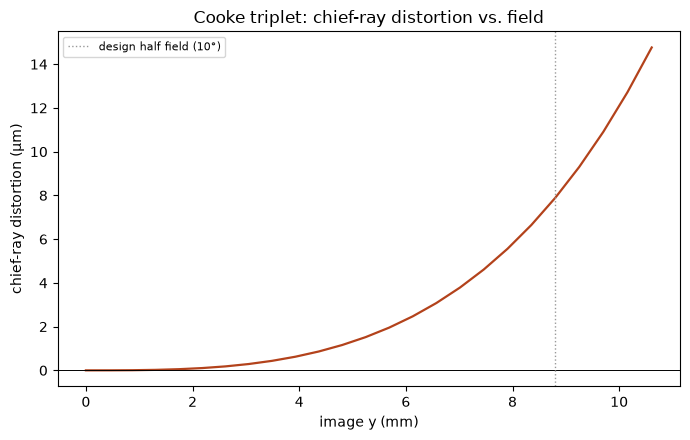

In [2]:
def chief_distortion(tracer, object_z, magnification, angle_deg, stop_index=None):
    if angle_deg == 0.0:
        return 0.0, 0.0, 0.0
    y = abs(object_z) * np.tan(np.deg2rad(angle_deg))
    sx, sy = chief_ray_slopes(tracer, FieldPoint(y=y), stop_index=stop_index)
    result = trace_from_object(tracer, (0.0, y), (sx, sy))
    ideal_y = y * magnification
    distortion_um = (result.image_point[1] - ideal_y) * 1e3
    ppm = (result.image_point[1] / ideal_y - 1) * 1e6
    return y * magnification, distortion_um, ppm


FIELDS_DEG = np.arange(0.0, 12.01, 0.5)
rows = []
for deg in FIELDS_DEG:
    try:
        rows.append(chief_distortion(tracer, conjugate.object_z, conjugate.magnification, deg))
    except RuntimeError:
        rows.append((np.nan, np.nan, np.nan))

n_dropped = sum(1 for r in rows if np.isnan(r[0]))
if n_dropped:
    print(f"note: {n_dropped}/{len(rows)} field angles vignetted and are omitted from the plot")

image_heights = [r[0] for r in rows]
distortions_um = [r[1] for r in rows]

print(f"{'field (deg)':>12} | {'image y (mm)':>13} | {'distortion (um)':>16} | {'relative (ppm)':>14}")
for deg, (ideal_y, d_um, ppm) in zip(FIELDS_DEG, rows):
    if not np.isnan(ideal_y):
        print(f"{deg:12.1f} | {ideal_y:13.4f} | {d_um:16.3f} | {ppm:14.1f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(image_heights, distortions_um, "-", color="#b3421b", lw=1.6)
ax.axhline(0, color="black", lw=0.7)
ax.axvline(abs(conjugate.object_z) * np.tan(np.deg2rad(10.0)) * conjugate.magnification,
           color="#999999", ls=":", lw=1, label="design half field (10°)")
ax.set(xlabel="image y (mm)", ylabel="chief-ray distortion (µm)",
       title="Cooke triplet: chief-ray distortion vs. field")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Distortion grid

The classic optical-design-software display: trace a square grid of
object points and see how it warps at the image plane. The grid spans the
design's 10° half field on each axis; distortion at this scale is far too
small to see at 1:1, so it is shown exaggerated (with the true-scale panel
alongside for reference).

grid coverage: 100.0% of 121 points traced without vignetting


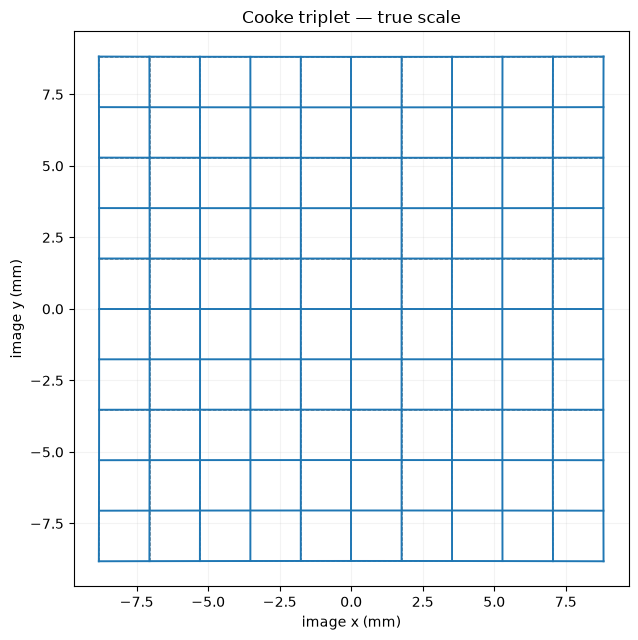

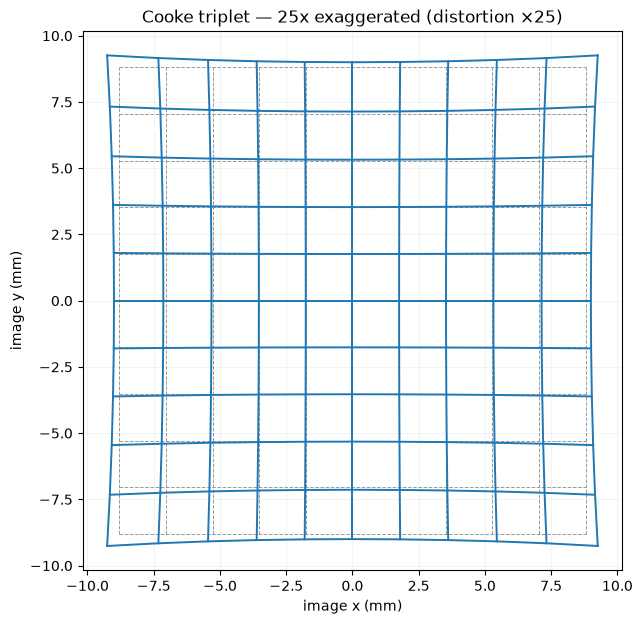

In [3]:
half = abs(conjugate.object_z) * np.tan(np.deg2rad(10.0))
grid = distortion_grid(tracer, magnification=conjugate.magnification, half_field=half, n=11)
print(f"grid coverage: {grid.valid_fraction:.1%} of {grid.valid.size} points traced without vignetting")

fig = plots.distortion_grid_figure(grid, exaggeration=1.0, title="Cooke triplet — true scale")
plt.show()
fig = plots.distortion_grid_figure(grid, exaggeration=25.0, title="Cooke triplet — 25x exaggerated")
plt.show()